# LADA v5: Sistema de Recomendacion Multinivel Optimizado

## Descripcion
Copia exacta de la metodologia de v4 (Level 1 propagation + progressive fallback)
con las siguientes correcciones:
- **Bug fix**: `range(1)` → `range(10)` en Random Search (v4 solo buscaba 1 iteracion)
- **Bug fix**: `sample(n=2000)` → `PCT_TEST_EVALUAR` configurable (v4 solo evaluaba 2000 casos)
- **Optimizacion**: Pre-computo de dicts numpy para lookup O(1) en vez de filtrado DataFrame O(n)
- **Pipeline corregido**: 7 fixes de data pipeline aplicados (parquet names, column names, type casts, etc.)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, silhouette_score
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import skfuzzy as fuzz
import random
import time
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

import math
print('Imports completados')

Imports completados


In [2]:
# Cargar los 6 datasets
DATA_PATH = '../data/'

df_materias = pd.read_parquet(f'{DATA_PATH}historial_materias_estudiante_anonymized.parquet')
print(f' Historial de materias: {df_materias.shape[0]:,} registros, {df_materias.shape[1]} columnas')

df_rendimiento = pd.read_parquet(f'{DATA_PATH}historial_rendimiento_academico_estudiante_anonymized.parquet')
print(f' Rendimiento academico: {df_rendimiento.shape[0]:,} registros, {df_rendimiento.shape[1]} columnas')

df_percentiles = pd.read_parquet(f'{DATA_PATH}percentiles_academicos_estudiante_anonymized.parquet')
print(f' Percentiles academicos: {df_percentiles.shape[0]:,} registros, {df_percentiles.shape[1]} columnas')

df_info_actual = pd.read_parquet(f'{DATA_PATH}informacion_actual_estudiante_anonymized.parquet')
print(f' Informacion actual: {df_info_actual.shape[0]:,} registros, {df_info_actual.shape[1]} columnas')

df_riesgos = pd.read_parquet(f'{DATA_PATH}riesgos_historicos_estudiante_pregrado_anonymized.parquet')
print(f' Riesgos historicos: {df_riesgos.shape[0]:,} registros, {df_riesgos.shape[1]} columnas')

df_facultades_departamentos = pd.read_parquet(f'{DATA_PATH}oferta_academica_anonymized.parquet')
print(f' Oferta Academica: {df_facultades_departamentos.shape[0]:,} registros, {df_facultades_departamentos.shape[1]} columnas')

 Historial de materias: 4,931,740 registros, 15 columnas
 Rendimiento academico: 611,654 registros, 22 columnas
 Percentiles academicos: 158,429 registros, 11 columnas
 Informacion actual: 222,407 registros, 30 columnas
 Riesgos historicos: 369,370 registros, 12 columnas
 Oferta Academica: 334,547 registros, 5 columnas


In [3]:
# ============================================================================
# PREPROCESAMIENTO DE MATERIAS
# ============================================================================
print('1. Procesando historial de materias...')

df_materias_clean = df_materias[
    (df_materias['NIVEL_ACADEMICO_ESTUDIANTE'] == 'Pregrado') &
    (df_materias['ESTATUS'] == 'HISTORIA') &
    (df_materias['RESULTADO'].isin(['APROBADO', 'REPROBADO', 'RETIRADO']))
].assign(
    EXITO=lambda x: (x['RESULTADO'] == 'APROBADO').astype('int8'),
    CODIGO_CURSO=lambda x: x['CODIGO_CURSO'].astype(str),
    PERIODO=lambda x: x['PERIODO'].astype(str)
)

# Deduplicar facultades por (CODIGO_CURSO, PERIODO)
df_facultades_clean = df_facultades_departamentos[
    ['CODIGO_CURSO', 'PERIODO', 'CODIGO_DEPARTAMENTO', 'CODIGO_FACULTAD']
].drop_duplicates(subset=['CODIGO_CURSO', 'PERIODO'], keep='first').astype({
    'CODIGO_CURSO': str,
    'PERIODO': str
})

# Merge por curso y periodo
df_materias_clean = df_materias_clean.merge(
    df_facultades_clean,
    on=['CODIGO_CURSO', 'PERIODO'],
    how='left',
    validate='m:1'
)

print(f'   Registros originales: {len(df_materias):,}')
print(f'   Registros despues de filtrado: {len(df_materias_clean):,}')
print(f'   Tasa de exito general: {df_materias_clean["EXITO"].mean()*100:.2f}%')
print(f'   Cursos con departamento: {df_materias_clean["CODIGO_DEPARTAMENTO"].notna().sum():,} ({df_materias_clean["CODIGO_DEPARTAMENTO"].notna().mean()*100:.1f}%)')

# ============================================================================
# PREPROCESAMIENTO DE RENDIMIENTO
# ============================================================================
print('\n2. Procesando rendimiento academico...')
df_rendimiento_clean = df_rendimiento[
    (df_rendimiento['PGA'].between(0, 5)) &
    (df_rendimiento['PORCENTAJE_CREDITOS_APROBADOS'].between(0, 100))
].copy()

print(f'   Registros originales: {len(df_rendimiento):,}')
print(f'   Registros despues de limpieza: {len(df_rendimiento_clean):,}')
print(f'   PGA promedio: {df_rendimiento_clean["PGA"].mean():.2f}')

# ============================================================================
# RIESGOS - usar solo las 5 columnas binarias especificas
# ============================================================================
print('\n3. Procesando indicadores de riesgo...')
df_riesgos_clean = df_riesgos.copy()

risk_binary_cols = [
    'bajo_promedio_segundo_semestre',
    'bajo_promedio_tercer_semestre_o_mas',
    'bajo_promedio_movil',
    'no_lectura_ingles_sexto_semestre',
    'porcentaje_creditos_aprobados_menor_50'
]

risk_cols_disponibles = [col for col in risk_binary_cols if col in df_riesgos_clean.columns]

if risk_cols_disponibles:
    for col in risk_cols_disponibles:
        df_riesgos_clean[col] = df_riesgos_clean[col].fillna(0).astype(int)
    df_riesgos_clean['RIESGO_SCORE'] = df_riesgos_clean[risk_cols_disponibles].sum(axis=1)
else:
    df_riesgos_clean['RIESGO_SCORE'] = 0

print(f'   Columnas de riesgo encontradas: {len(risk_cols_disponibles)}/{len(risk_binary_cols)}')
print(f'   Score de riesgo promedio: {df_riesgos_clean["RIESGO_SCORE"].mean():.2f}')

print('\nPreprocesamiento completado.')

1. Procesando historial de materias...
   Registros originales: 4,931,740
   Registros despues de filtrado: 3,624,475
   Tasa de exito general: 93.77%
   Cursos con departamento: 3,624,358 (100.0%)

2. Procesando rendimiento academico...
   Registros originales: 611,654
   Registros despues de limpieza: 611,654
   PGA promedio: 3.97

3. Procesando indicadores de riesgo...
   Columnas de riesgo encontradas: 5/5
   Score de riesgo promedio: 1.04

Preprocesamiento completado.


In [4]:
# ============================================================================
# CONSTRUCCION DE NIVELES JERARQUICOS
# ============================================================================
usar_departamento_nivel2 = True

print('Procesando inscripciones por semestre...')

# Agrupar materias por estudiante y periodo
df_inscripciones = df_materias_clean.groupby(['CODIGO_ESTUDIANTE', 'PERIODO'], as_index=False).agg({
    'CODIGO_CURSO': list,
    'NUMERO_CREDITOS': ['sum', 'count'],
    'EXITO': 'mean'
})

# Aplanar nombres de columnas
df_inscripciones.columns = ['CODIGO_ESTUDIANTE', 'PERIODO', 'CURSOS_LISTA',
                             'CREDITOS_TOTALES', 'NUM_CURSOS', 'TASA_EXITO']

print(f'  Procesados {len(df_inscripciones):,} semestres de inscripciones')

# NIVEL 1: Numero total de cursos
print('\nConstruyendo Nivel 1 (Numero total de cursos)...')
df_inscripciones['NIVEL_1'] = df_inscripciones['NUM_CURSOS'].astype(str)
print(f'Distribucion Nivel 1:')
print(df_inscripciones['NIVEL_1'].value_counts().head(10))

# PREPARAR MAPEO: Crear diccionario curso -> categoria UNA SOLA VEZ
print(f'\nPreparando mapeo curso -> categoria...')
col_categoria = 'CODIGO_DEPARTAMENTO' if usar_departamento_nivel2 else 'CODIGO_FACULTAD'
prefijo = 'DEPT_' if usar_departamento_nivel2 else 'FAC_'

# Mapeo eficiente: curso -> categoria (identico al v4)
mapeo_curso_cat = df_facultades_departamentos.drop_duplicates(subset=['CODIGO_CURSO']).set_index('CODIGO_CURSO')[col_categoria].to_dict()

# Rellenar con 'DESCONOCIDO' para cursos no encontrados o NaN
mapeo_curso_cat = {k: f"{prefijo}{v}" if pd.notna(v) else 'DESCONOCIDO'
                   for k, v in mapeo_curso_cat.items()}

# NIVEL 2: Numero de cursos por categoria
print(f'\nConstruyendo Nivel 2 (usando {"DEPARTAMENTO" if usar_departamento_nivel2 else "FACULTAD"})...')

def construir_nivel_2(cursos_lista):
    categorias = [mapeo_curso_cat.get(str(curso), 'DESCONOCIDO') for curso in cursos_lista]
    contador = pd.Series(categorias).value_counts().to_dict()
    firma = '_'.join([f"{cat}:{count}" for cat, count in sorted(contador.items())])
    return firma

df_inscripciones['NIVEL_2'] = df_inscripciones['CURSOS_LISTA'].apply(construir_nivel_2)
print(f'Categorias unicas en Nivel 2: {df_inscripciones["NIVEL_2"].nunique():,}')

# NIVEL 3: Codigos especificos de cursos
print('\nConstruyendo Nivel 3 (Codigos especificos de cursos)...')

df_inscripciones['NIVEL_3'] = df_inscripciones['CURSOS_LISTA'].apply(
    lambda x: '_'.join(sorted([str(c) for c in x]))
)
print(f'Combinaciones unicas en Nivel 3: {df_inscripciones["NIVEL_3"].nunique():,}')

print(f'\nNIVELES CONSTRUIDOS - NIVEL_2 usa: {"DEPARTAMENTO" if usar_departamento_nivel2 else "FACULTAD"}')

Procesando inscripciones por semestre...
  Procesados 698,436 semestres de inscripciones

Construyendo Nivel 1 (Numero total de cursos)...
Distribucion Nivel 1:
NIVEL_1
6     178947
7     114850
5     110205
1      85506
8      54032
3      42511
4      42135
2      38131
9      20652
10      7648
Name: count, dtype: int64

Preparando mapeo curso -> categoria...

Construyendo Nivel 2 (usando DEPARTAMENTO)...
Categorias unicas en Nivel 2: 234,407

Construyendo Nivel 3 (Codigos especificos de cursos)...
Combinaciones unicas en Nivel 3: 534,811

NIVELES CONSTRUIDOS - NIVEL_2 usa: DEPARTAMENTO


In [5]:
# ============================================================================
# CALCULO DE PGA_ANTERIOR (prevencion de data leakage)
# ============================================================================
def calcular_pga_anterior(df_inscripciones, df_rendimiento, df_info_actual):
    print('Calculando PGA_ANTERIOR...')
    df_ins = df_inscripciones[['CODIGO_ESTUDIANTE', 'PERIODO']].copy()
    
    df_hist = df_rendimiento[[
        'CODIGO_ESTUDIANTE', 'PERIODO', 'PGA',
        'TOTAL_SEMESTRES_MATRICULADOS', 'PORCENTAJE_CREDITOS_APROBADOS'
    ]].copy()
    df_hist['PGA'] = pd.to_numeric(df_hist['PGA'], errors='coerce')
    df_hist['TOTAL_SEMESTRES_MATRICULADOS'] = pd.to_numeric(df_hist['TOTAL_SEMESTRES_MATRICULADOS'], errors='coerce')
    df_hist['PORCENTAJE_CREDITOS_APROBADOS'] = pd.to_numeric(df_hist['PORCENTAJE_CREDITOS_APROBADOS'], errors='coerce')
    
    pct_creditos_promedio = df_hist['PORCENTAJE_CREDITOS_APROBADOS'].mean()
    print(f'  Promedio general de % creditos aprobados: {pct_creditos_promedio:.2f}%')
    
    df_hist = df_hist.rename(columns={
        'PERIODO': 'PERIODO_HIST', 'PGA': 'PGA_HIST',
        'TOTAL_SEMESTRES_MATRICULADOS': 'SEMESTRES_HIST',
        'PORCENTAJE_CREDITOS_APROBADOS': 'PCT_CREDITOS_HIST'
    })
    
    df_icfes = df_info_actual[['CODIGO_ESTUDIANTE', 'PUNTAJE_ICFES']].copy()
    df_icfes['PUNTAJE_ICFES'] = pd.to_numeric(df_icfes['PUNTAJE_ICFES'], errors='coerce')
    
    df_ins = df_ins.sort_values('PERIODO')
    df_hist = df_hist.sort_values('PERIODO_HIST')
    
    df_merged = pd.merge_asof(
        df_ins, df_hist,
        left_on='PERIODO', right_on='PERIODO_HIST',
        by='CODIGO_ESTUDIANTE',
        direction='backward',
        allow_exact_matches=False
    )
    
    df_final = pd.merge(df_merged, df_icfes, on='CODIGO_ESTUDIANTE', how='left')
    
    tiene_historia = df_final['PGA_HIST'].notna()
    tiene_icfes = df_final['PUNTAJE_ICFES'].notna()
    
    df_final['PGA_ANTERIOR'] = np.nan
    df_final['SEMESTRES_ANTERIORES'] = np.nan
    df_final['PCT_CREDITOS_ANTERIOR'] = np.nan
    df_final['FUENTE_PGA'] = 'SIN_DATOS'
    
    # Caso 1: Tiene historial
    df_final.loc[tiene_historia, 'PGA_ANTERIOR'] = df_final.loc[tiene_historia, 'PGA_HIST']
    df_final.loc[tiene_historia, 'SEMESTRES_ANTERIORES'] = df_final.loc[tiene_historia, 'SEMESTRES_HIST']
    df_final.loc[tiene_historia, 'PCT_CREDITOS_ANTERIOR'] = df_final.loc[tiene_historia, 'PCT_CREDITOS_HIST']
    df_final.loc[tiene_historia, 'PERIODO_FUENTE_PGA'] = df_final.loc[tiene_historia, 'PERIODO_HIST']
    df_final.loc[tiene_historia, 'FUENTE_PGA'] = 'PGA_HISTORICO'
    
    # Caso 2: No tiene historial, usa ICFES
    mask_icfes = (~tiene_historia) & (tiene_icfes)
    df_final.loc[mask_icfes, 'PGA_ANTERIOR'] = (df_final.loc[mask_icfes, 'PUNTAJE_ICFES'] / 500.0) * 5.0
    df_final.loc[mask_icfes, 'SEMESTRES_ANTERIORES'] = 0
    df_final.loc[mask_icfes, 'PCT_CREDITOS_ANTERIOR'] = pct_creditos_promedio
    df_final.loc[mask_icfes, 'FUENTE_PGA'] = 'ICFES_NORMALIZADO'
    
    print(f'  Con historial: {tiene_historia.sum():,}')
    print(f'  Con ICFES: {mask_icfes.sum():,}')
    print(f'  Sin datos: {(~tiene_historia & ~tiene_icfes).sum():,}')
    
    resultado = df_final[[
        'CODIGO_ESTUDIANTE', 'PERIODO', 'PGA_ANTERIOR',
        'SEMESTRES_ANTERIORES', 'PCT_CREDITOS_ANTERIOR',
        'PERIODO_FUENTE_PGA', 'FUENTE_PGA'
    ]].copy()
    
    return resultado

# CRITICO: Convertir PERIODO a int en todos los DataFrames antes de merge_asof
df_inscripciones['PERIODO'] = df_inscripciones['PERIODO'].astype(int)
df_rendimiento_clean['PERIODO'] = df_rendimiento_clean['PERIODO'].astype(int)
df_info_actual['PERIODO'] = df_info_actual['PERIODO'].astype(int)

resultado_pga = calcular_pga_anterior(df_inscripciones, df_rendimiento_clean, df_info_actual)

# Merge con inscripciones
df_inscripciones = df_inscripciones.merge(
    resultado_pga, on=['CODIGO_ESTUDIANTE', 'PERIODO'], how='left'
)

print(f'\nDistribucion de fuentes de PGA:')
print(df_inscripciones['FUENTE_PGA'].value_counts())

# Eliminar registros sin PGA_ANTERIOR
antes = len(df_inscripciones)
df_inscripciones = df_inscripciones.dropna(subset=['PGA_ANTERIOR']).copy()
print(f'\nRegistros totales: {antes:,}')
print(f'Registros con PGA valido: {len(df_inscripciones):,}')
print(f'Registros descartados (sin PGA ni ICFES): {antes - len(df_inscripciones):,}')
print(f'\nDataset final: {len(df_inscripciones):,} registros')

Calculando PGA_ANTERIOR...
  Promedio general de % creditos aprobados: 0.89%
  Con historial: 415,787
  Con ICFES: 31,669
  Sin datos: 250,980

Distribucion de fuentes de PGA:
FUENTE_PGA
PGA_HISTORICO        415787
SIN_DATOS            250980
ICFES_NORMALIZADO     31669
Name: count, dtype: int64

Registros totales: 698,436
Registros con PGA valido: 447,456
Registros descartados (sin PGA ni ICFES): 250,980

Dataset final: 447,456 registros


In [6]:
# ============================================================================
# SPLIT TEMPORAL
# ============================================================================
PERIODO_TRAIN_END = 202010
PERIODO_VAL_END = 202310

df_train = df_inscripciones[df_inscripciones['PERIODO'] <= PERIODO_TRAIN_END].copy()
df_val = df_inscripciones[
    (df_inscripciones['PERIODO'] > PERIODO_TRAIN_END) &
    (df_inscripciones['PERIODO'] <= PERIODO_VAL_END)
].copy()
df_test = df_inscripciones[df_inscripciones['PERIODO'] > PERIODO_VAL_END].copy()

print(f'TRAIN (<=202010): {len(df_train):,} registros')
print(f'VAL (202011-202310): {len(df_val):,} registros')
print(f'TEST (>202310): {len(df_test):,} registros')
print(f'Total: {len(df_train) + len(df_val) + len(df_test):,}')

TRAIN (<=202010): 285,158 registros
VAL (202011-202310): 90,019 registros
TEST (>202310): 72,279 registros
Total: 447,456


In [7]:
# ============================================================================
# FEATURES PARA CLUSTERING
# ============================================================================
FEATURE_COLS = ['PGA_ANTERIOR', 'SEMESTRES_ANTERIORES', 'PCT_CREDITOS_ANTERIOR',
                'NUM_CURSOS', 'CREDITOS_TOTALES']

# ============================================================================
# ESPACIOS DE HIPERPARAMETROS
# ============================================================================
PARAM_SPACES = {
    'fuzzy': {
        'n_clusters': [2, 3, 4, 5],
        'm': [1.5, 2.0, 2.5, 3.0],
        'error': [0.001, 0.005, 0.01],
        'maxiter': [1000]
    },
    'kmeans': {
        'n_clusters': [2, 3, 4, 5],
        'init': ['k-means++', 'random'],
        'n_init': [10, 20],
        'max_iter': [300, 500]
    },
    'gmm': {
        'n_components': [2, 3, 4, 5],
        'covariance_type': ['full', 'tied', 'diag'],
        'max_iter': [100, 200],
        'n_init': [1, 3]
    }
}

def sample_random_params(param_space, seed=None):
    if seed is not None:
        random.seed(seed)
    return {key: random.choice(values) for key, values in param_space.items()}

print('Espacios de hiperparametros definidos')
for algo, space in PARAM_SPACES.items():
    total = 1
    for v in space.values():
        total *= len(v)
    print(f'  {algo}: {total} combinaciones posibles')

Espacios de hiperparametros definidos
  fuzzy: 48 combinaciones posibles
  kmeans: 32 combinaciones posibles
  gmm: 48 combinaciones posibles


In [8]:
# ============================================================================
# FUNCIONES DE CLUSTERING (identicas al v4)
# ============================================================================

def fuzzy_cmeans_clustering(X_scaled, tasa_exito, params):
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        X_scaled.T, c=params['n_clusters'], m=params['m'],
        error=params['error'], maxiter=params['maxiter']
    )
    labels = np.argmax(u, axis=0)
    tasas = {}
    tamanos = {}
    for k in range(params['n_clusters']):
        mask = labels == k
        if mask.any():
            tasas[k] = float(tasa_exito[mask].mean())
            tamanos[k] = int(mask.sum())
    return {'centroides': cntr, 'tasas_exito': tasas, 'tamanos_cluster': tamanos,
            'n_clusters': params['n_clusters'], 'algoritmo': 'fuzzy'}

def kmeans_clustering(X_scaled, tasa_exito, params):
    km = KMeans(n_clusters=params['n_clusters'], init=params['init'],
                n_init=params['n_init'], max_iter=params['max_iter'], random_state=42)
    labels = km.fit_predict(X_scaled)
    tasas = {}
    tamanos = {}
    for k in range(params['n_clusters']):
        mask = labels == k
        if mask.any():
            tasas[k] = float(tasa_exito[mask].mean())
            tamanos[k] = int(mask.sum())
    return {'centroides': km.cluster_centers_, 'tasas_exito': tasas,
            'tamanos_cluster': tamanos, 'n_clusters': params['n_clusters'],
            'algoritmo': 'kmeans'}

def gmm_clustering(X_scaled, tasa_exito, params):
    gmm = GaussianMixture(n_components=params['n_components'],
                          covariance_type=params['covariance_type'],
                          max_iter=params['max_iter'], n_init=params['n_init'],
                          random_state=42)
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)
    tasas = {}
    tamanos = {}
    for k in range(params['n_components']):
        mask = labels == k
        if mask.any():
            tasas[k] = float(tasa_exito[mask].mean())
            tamanos[k] = int(mask.sum())
    return {'centroides': gmm.means_, 'tasas_exito': tasas,
            'tamanos_cluster': tamanos, 'n_clusters': params['n_components'],
            'algoritmo': 'gmm'}

CLUSTERING_FUNCS = {
    'fuzzy': fuzzy_cmeans_clustering,
    'kmeans': kmeans_clustering,
    'gmm': gmm_clustering
}

print('Funciones de clustering definidas: fuzzy, kmeans, gmm')

Funciones de clustering definidas: fuzzy, kmeans, gmm


In [ ]:
# ============================================================================
# FASE 1: SELECCION DE ALGORITMO GLOBAL
# Prueba 3 algoritmos en muestras representativas de los 3 niveles
# Selecciona 1 algoritmo global basado en MAE promedio de TODAS las muestras
# ============================================================================
N_ITER_SEARCH = 10

# Formula de Cochran para tamano de muestra de poblacion finita
def cochran_sample_size(N, confidence=0.95, margin_error=0.05, p=0.5):
    """Calcula tamano de muestra con formula de Cochran."""
    Z = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}[confidence]
    n0 = (Z**2 * p * (1 - p)) / (margin_error**2)
    n = n0 / (1 + (n0 - 1) / N)
    return int(math.ceil(n))

print("=" * 70)
print("FASE 1: SELECCION DE ALGORITMO GLOBAL")
print(f"Random Search: {N_ITER_SEARCH} iteraciones por algoritmo por combinacion")
print("=" * 70)

# Pool global de MAEs por algoritmo (se juntan resultados de los 3 niveles)
mae_pool_por_algoritmo = {'fuzzy': [], 'kmeans': [], 'gmm': []}

# Para tracking
muestras_por_nivel = {}

for nivel_nombre in ['NIVEL_1', 'NIVEL_2', 'NIVEL_3']:
    print(f"\n{'='*70}")
    print(f"Evaluando algoritmos en {nivel_nombre}...")
    print(f"{'='*70}")
    
    # Preparar features para TRAIN y VAL en este nivel
    df_train_nivel = df_train.dropna(subset=FEATURE_COLS).copy()
    df_val_nivel = df_val.dropna(subset=FEATURE_COLS).copy()
    
    X_train_raw = df_train_nivel[FEATURE_COLS].values
    X_val_raw = df_val_nivel[FEATURE_COLS].values
    
    # Scaler global por nivel
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_raw)
    X_val_s = scaler.transform(X_val_raw)
    
    # Pre-computar indices por combinacion
    train_ids = df_train_nivel[nivel_nombre].values
    val_ids = df_val_nivel[nivel_nombre].values
    train_tasa = df_train_nivel['TASA_EXITO'].values
    val_tasa = df_val_nivel['TASA_EXITO'].values
    
    train_idx_by_comb = {}
    for i, c in enumerate(train_ids):
        if c not in train_idx_by_comb:
            train_idx_by_comb[c] = []
        train_idx_by_comb[c].append(i)
    train_idx_by_comb = {k: np.array(v) for k, v in train_idx_by_comb.items()}
    
    val_idx_by_comb = {}
    for i, c in enumerate(val_ids):
        if c not in val_idx_by_comb:
            val_idx_by_comb[c] = []
        val_idx_by_comb[c].append(i)
    val_idx_by_comb = {k: np.array(v) for k, v in val_idx_by_comb.items()}
    
    # Filtrar combinaciones con suficientes datos
    combs_validas = []
    for comb in train_idx_by_comb:
        n_train = len(train_idx_by_comb[comb])
        n_val = len(val_idx_by_comb.get(comb, []))
        if n_train >= 10 and n_val >= 5:
            combs_validas.append(comb)
    
    N_total = len(combs_validas)
    print(f"  Combinaciones con datos suficientes: {N_total}")
    
    if N_total == 0:
        print(f"  [SKIP] Sin combinaciones validas")
        muestras_por_nivel[nivel_nombre] = {'total': 0, 'muestra': 0}
        continue
    
    # Calcular tamano de muestra con Cochran
    n_muestra = cochran_sample_size(N_total)
    n_muestra = min(n_muestra, N_total)  # no mas que el total
    
    # Muestrear
    np.random.seed(42)
    if n_muestra >= N_total:
        combs_muestra = combs_validas
    else:
        indices_muestra = np.random.choice(N_total, size=n_muestra, replace=False)
        combs_muestra = [combs_validas[i] for i in indices_muestra]
    
    muestras_por_nivel[nivel_nombre] = {'total': N_total, 'muestra': len(combs_muestra)}
    print(f"  Muestra Cochran (95% conf, 5% margen): {len(combs_muestra)} de {N_total}")
    
    # Evaluar 3 algoritmos en cada combinacion muestreada
    for idx_comb, comb in enumerate(combs_muestra):
        if (idx_comb + 1) % max(1, len(combs_muestra) // 5) == 0:
            print(f"    Progreso: {idx_comb + 1}/{len(combs_muestra)}")
        
        idx_tr = train_idx_by_comb[comb]
        idx_vl = val_idx_by_comb[comb]
        
        X_comb_tr = X_train_s[idx_tr]
        tasa_comb_tr = train_tasa[idx_tr]
        X_comb_vl = X_val_s[idx_vl]
        tasa_comb_vl = val_tasa[idx_vl]
        
        n_clusters_max = min(5, max(2, len(idx_tr) // 10))
        
        for algo_name in ['fuzzy', 'kmeans', 'gmm']:
            param_space = PARAM_SPACES[algo_name].copy()
            
            if 'n_clusters' in param_space:
                param_space['n_clusters'] = [n for n in param_space['n_clusters'] if n <= n_clusters_max]
            if 'n_components' in param_space:
                param_space['n_components'] = [n for n in param_space['n_components'] if n <= n_clusters_max]
            
            if not param_space.get('n_clusters', [True]) and not param_space.get('n_components', [True]):
                continue
            
            mejor_mae = float('inf')
            
            for iter_num in range(N_ITER_SEARCH):
                params = sample_random_params(param_space, seed=42 + iter_num)
                try:
                    resultado = CLUSTERING_FUNCS[algo_name](X_comb_tr, tasa_comb_tr, params)
                    centroides = resultado['centroides']
                    dist = np.linalg.norm(X_comb_vl[:, np.newaxis, :] - centroides[np.newaxis, :, :], axis=2)
                    clusters_asig = np.argmin(dist, axis=1)
                    preds = np.array([resultado['tasas_exito'].get(int(c), 0.0) for c in clusters_asig])
                    mae = mean_absolute_error(tasa_comb_vl, preds)
                    if mae < mejor_mae:
                        mejor_mae = mae
                except:
                    continue
            
            if mejor_mae < float('inf'):
                mae_pool_por_algoritmo[algo_name].append(mejor_mae)

# ============================================================================
# SELECCION DEL ALGORITMO GANADOR
# ============================================================================
print("\n" + "=" * 70)
print("RESULTADOS DE SELECCION DE ALGORITMO GLOBAL")
print("=" * 70)

print(f"\nMuestras por nivel:")
for nivel, info in muestras_por_nivel.items():
    print(f"  {nivel}: {info['muestra']} de {info['total']} combinaciones")

total_muestras = sum(len(v) for v in mae_pool_por_algoritmo.values()) // 3
print(f"\nTotal de evaluaciones por algoritmo: ~{total_muestras}")

mae_promedio_global = {}
for algo, maes in mae_pool_por_algoritmo.items():
    if maes:
        mae_promedio_global[algo] = np.mean(maes)
        print(f"\n  {algo.upper()}:")
        print(f"    MAE promedio global: {np.mean(maes):.4f}")
        print(f"    MAE std: {np.std(maes):.4f}")
        print(f"    Evaluaciones: {len(maes)}")

ALGORITMO_GANADOR = min(mae_promedio_global, key=mae_promedio_global.get)
print(f"\n{'='*70}")
print(f"ALGORITMO GANADOR: {ALGORITMO_GANADOR.upper()} (MAE global = {mae_promedio_global[ALGORITMO_GANADOR]:.4f})")
print(f"{'='*70}")

In [ ]:
# ============================================================================
# FASE 2: BUSQUEDA DE HIPERPARAMETROS CON ALGORITMO GANADOR
# Entrena con el algoritmo seleccionado en TODAS las combinaciones de los 3 niveles
# ============================================================================
print("=" * 70)
print(f"FASE 2: ENTRENAMIENTO CON {ALGORITMO_GANADOR.upper()} EN 3 NIVELES")
print("=" * 70)

resultados_por_nivel = {}

for nivel_nombre in ['NIVEL_1', 'NIVEL_2', 'NIVEL_3']:
    print(f"\n{'='*70}")
    print(f"Entrenando {nivel_nombre} con {ALGORITMO_GANADOR.upper()}...")
    print(f"{'='*70}")
    tiempo_inicio = time.time()
    
    # Preparar features
    df_nivel = df_train.dropna(subset=FEATURE_COLS).copy()
    X_nivel = df_nivel[FEATURE_COLS].values
    
    if len(X_nivel) == 0:
        resultados_por_nivel[nivel_nombre] = {
            'clusters': {}, 'total_combinaciones': 0, 'combinaciones_con_clusters': 0
        }
        continue
    
    # Scaler global por nivel
    scaler_nivel = StandardScaler()
    X_scaled_nivel = scaler_nivel.fit_transform(X_nivel)
    
    # Pre-computar indices
    nivel_ids = df_nivel[nivel_nombre].values
    tasa_nivel = df_nivel['TASA_EXITO'].values
    
    indices_by_comb = {}
    for i, c in enumerate(nivel_ids):
        if c not in indices_by_comb:
            indices_by_comb[c] = []
        indices_by_comb[c].append(i)
    indices_by_comb = {k: np.array(v) for k, v in indices_by_comb.items()}
    
    # Preparar VAL para este nivel
    df_val_nivel = df_val.dropna(subset=FEATURE_COLS).copy()
    X_val_nivel = df_val_nivel[FEATURE_COLS].values
    X_val_scaled = scaler_nivel.transform(X_val_nivel)
    val_ids = df_val_nivel[nivel_nombre].values
    val_tasa = df_val_nivel['TASA_EXITO'].values
    
    val_idx_by_comb = {}
    for i, c in enumerate(val_ids):
        if c not in val_idx_by_comb:
            val_idx_by_comb[c] = []
        val_idx_by_comb[c].append(i)
    val_idx_by_comb = {k: np.array(v) for k, v in val_idx_by_comb.items()}
    
    combinaciones = list(indices_by_comb.keys())
    print(f"  Combinaciones totales: {len(combinaciones):,}")
    
    clusters_por_combinacion = {}
    total_combs = len(combinaciones)
    umbral_progreso = max(1, total_combs // 10)
    
    param_space_ganador = PARAM_SPACES[ALGORITMO_GANADOR].copy()
    
    for idx, comb in enumerate(combinaciones):
        if (idx + 1) % umbral_progreso == 0 or idx == 0:
            print(f"    Progreso: {idx + 1}/{total_combs} ({(idx+1)/total_combs*100:.1f}%)")
        
        idx_comb = indices_by_comb[comb]
        X_comb = X_scaled_nivel[idx_comb]
        tasa_comb = tasa_nivel[idx_comb]
        
        if len(idx_comb) < 10:
            continue
        
        n_clusters = min(5, max(2, len(idx_comb) // 10))
        
        # Ajustar param space
        ps = param_space_ganador.copy()
        if 'n_clusters' in ps:
            ps['n_clusters'] = [n for n in ps['n_clusters'] if n <= n_clusters]
        if 'n_components' in ps:
            ps['n_components'] = [n for n in ps['n_components'] if n <= n_clusters]
        
        if not ps.get('n_clusters', [True]) and not ps.get('n_components', [True]):
            continue
        
        # Random Search con N_ITER_SEARCH iteraciones
        mejor_mae = float('inf')
        mejor_resultado = None
        mejor_params = None
        
        # Obtener datos de VAL para esta combinacion (si existen)
        idx_val_comb = val_idx_by_comb.get(comb, np.array([], dtype=int))
        tiene_val = len(idx_val_comb) >= 5
        
        for iter_num in range(N_ITER_SEARCH):
            params = sample_random_params(ps, seed=42 + iter_num)
            try:
                resultado = CLUSTERING_FUNCS[ALGORITMO_GANADOR](X_comb, tasa_comb, params)
                
                if tiene_val:
                    # Evaluar en VAL
                    X_val_c = X_val_scaled[idx_val_comb]
                    tasa_val_c = val_tasa[idx_val_comb]
                    centroides = resultado['centroides']
                    dist = np.linalg.norm(X_val_c[:, np.newaxis, :] - centroides[np.newaxis, :, :], axis=2)
                    clusters_asig = np.argmin(dist, axis=1)
                    preds = np.array([resultado['tasas_exito'].get(int(c), 0.0) for c in clusters_asig])
                    mae = mean_absolute_error(tasa_val_c, preds)
                else:
                    # Sin VAL: usar silhouette como proxy (menor es mejor -> negado)
                    mae = -resultado.get('silhouette', 0)  # placeholder
                
                if mae < mejor_mae:
                    mejor_mae = mae
                    mejor_resultado = resultado
                    mejor_params = params
            except:
                continue
        
        if mejor_resultado is not None:
            clusters_por_combinacion[comb] = {
                'n_clusters': mejor_resultado['n_clusters'],
                'centroides': mejor_resultado['centroides'],
                'scaler': scaler_nivel,
                'tasas_exito': mejor_resultado['tasas_exito'],
                'tamanos_cluster': mejor_resultado['tamanos_cluster'],
                'total_casos': len(idx_comb),
                'algoritmo': ALGORITMO_GANADOR,
                'hiperparametros': mejor_params
            }
    
    tiempo_total = time.time() - tiempo_inicio
    resultados_por_nivel[nivel_nombre] = {
        'clusters': clusters_por_combinacion,
        'total_combinaciones': len(combinaciones),
        'combinaciones_con_clusters': len(clusters_por_combinacion)
    }
    
    print(f"   {len(clusters_por_combinacion):,}/{len(combinaciones):,} completadas en {tiempo_total:.1f}s")

print("\n" + "=" * 70)
print(f"ENTRENAMIENTO COMPLETADO CON {ALGORITMO_GANADOR.upper()} EN 3 NIVELES")
print("=" * 70)
for nivel, info in resultados_por_nivel.items():
    print(f"\n{nivel}:")
    print(f"  Combinaciones totales: {info['total_combinaciones']:,}")
    print(f"  Combinaciones con clusters: {info['combinaciones_con_clusters']:,}")

In [11]:
# ============================================================================
# EVALUACION EN TEST SET
# BUG FIX: v4 usaba sample(n=2000), ahora configurable con PCT_TEST_EVALUAR
# ============================================================================
PCT_TEST_EVALUAR = 1.0  # 1.0 = 100% del test set

df_prueba = df_test.copy()
n_original = len(df_prueba)

if PCT_TEST_EVALUAR < 1.0:
    n_sample = int(len(df_prueba) * PCT_TEST_EVALUAR)
    df_prueba = df_prueba.sample(n=n_sample, random_state=42)

print(f"EVALUACION EN TEST SET")
print(f"  PCT_TEST_EVALUAR: {PCT_TEST_EVALUAR*100:.0f}%")
print(f"  Casos originales: {n_original:,}")
print(f"  Casos a evaluar: {len(df_prueba):,}")

# Construir firmas de test
print("\nConstruyendo firmas para test...")
test_firmas = []
for _, row in df_prueba.iterrows():
    cursos = row['CURSOS_LISTA']
    firma_1 = str(row['NUM_CURSOS'])
    
    categorias = [mapeo_curso_cat.get(str(c), 'DESCONOCIDO') for c in cursos]
    contador = pd.Series(categorias).value_counts().to_dict()
    firma_2 = '_'.join([f"{cat}:{count}" for cat, count in sorted(contador.items())])
    
    firma_3 = '_'.join(sorted([str(c) for c in cursos]))
    
    features = [row.get(col, np.nan) for col in FEATURE_COLS]
    
    test_firmas.append({
        'firma_1': firma_1,
        'firma_2': firma_2,
        'firma_3': firma_3,
        'features': features,
        'tasa_real': row['TASA_EXITO'],
        'pga_anterior': row.get('PGA_ANTERIOR', np.nan),
        'fuente_pga': row.get('FUENTE_PGA', 'DESCONOCIDO')
    })

print(f"  Firmas construidas: {len(test_firmas):,}")

# Progressive fallback: NIVEL_3 -> NIVEL_2 -> NIVEL_1
print("\nEvaluando con progressive fallback...")
predicciones = []
reales = []
niveles_usados = []
coberturas = {'NIVEL_3': 0, 'NIVEL_2': 0, 'NIVEL_1': 0, 'SIN_PREDICCION': 0}

UMBRALES = {'NIVEL_3': 20, 'NIVEL_2': 10, 'NIVEL_1': 5}

for firma_info in test_firmas:
    features = np.array(firma_info['features'])
    
    if np.any(np.isnan(features)):
        coberturas['SIN_PREDICCION'] += 1
        continue
    
    prediccion = None
    nivel_usado = None
    
    for nivel_nombre, firma_key in [('NIVEL_3', 'firma_3'), ('NIVEL_2', 'firma_2'), ('NIVEL_1', 'firma_1')]:
        firma = firma_info[firma_key]
        clusters = resultados_por_nivel.get(nivel_nombre, {}).get('clusters', {})
        
        if firma in clusters:
            info = clusters[firma]
            if info['total_casos'] >= UMBRALES[nivel_nombre]:
                # Normalizar features con el scaler del nivel
                scaler = info['scaler']
                features_norm = scaler.transform([features])[0]
                
                # Asignar al cluster mas cercano
                centroides = info['centroides']
                distancias = np.linalg.norm(centroides - features_norm, axis=1)
                cluster_id = int(np.argmin(distancias))
                
                prediccion = info['tasas_exito'].get(cluster_id, 0.0)
                nivel_usado = nivel_nombre
                break
    
    if prediccion is not None:
        predicciones.append(prediccion)
        reales.append(firma_info['tasa_real'])
        niveles_usados.append(nivel_usado)
        coberturas[nivel_usado] += 1
    else:
        coberturas['SIN_PREDICCION'] += 1

# Calcular metricas
predicciones = np.array(predicciones)
reales = np.array(reales)

mae = mean_absolute_error(reales, predicciones)
rmse = np.sqrt(mean_squared_error(reales, predicciones))
errores = np.abs(reales - predicciones)
acc_10 = (errores <= 0.10).mean() * 100
acc_20 = (errores <= 0.20).mean() * 100
cobertura = len(predicciones) / len(test_firmas) * 100

print(f"\n{'='*70}")
print(f"RESULTADOS EN TEST SET (v5 - Level 1 Propagation)")
print(f"{'='*70}")
print(f"  MAE:         {mae:.4f}")
print(f"  RMSE:        {rmse:.4f}")
print(f"  Acc +/-10%:  {acc_10:.1f}%")
print(f"  Acc +/-20%:  {acc_20:.1f}%")
print(f"  Cobertura:   {cobertura:.1f}% ({len(predicciones):,}/{len(test_firmas):,})")

print(f"\nDistribucion de niveles usados:")
total_pred = sum(v for k, v in coberturas.items() if k != 'SIN_PREDICCION')
for nivel, count in coberturas.items():
    pct = count / len(test_firmas) * 100
    print(f"  {nivel}: {count:,} ({pct:.1f}%)")

# Metricas por nivel
print(f"\nMetricas por nivel:")
for nivel_nombre in ['NIVEL_1', 'NIVEL_2', 'NIVEL_3']:
    mask_nivel = np.array(niveles_usados) == nivel_nombre
    if mask_nivel.any():
        mae_nivel = mean_absolute_error(reales[mask_nivel], predicciones[mask_nivel])
        acc10_nivel = (np.abs(reales[mask_nivel] - predicciones[mask_nivel]) <= 0.10).mean() * 100
        print(f"  {nivel_nombre}: MAE={mae_nivel:.4f}, Acc+/-10%={acc10_nivel:.1f}%, n={mask_nivel.sum():,}")

EVALUACION EN TEST SET
  PCT_TEST_EVALUAR: 100%
  Casos originales: 72,279
  Casos a evaluar: 72,279

Construyendo firmas para test...
  Firmas construidas: 72,279

Evaluando con progressive fallback...

RESULTADOS EN TEST SET (v5 - Level 1 Propagation)
  MAE:         0.0912
  RMSE:        0.1658
  Acc +/-10%:  73.3%
  Acc +/-20%:  87.4%
  Cobertura:   100.0% (72,274/72,279)

Distribucion de niveles usados:
  NIVEL_3: 6,248 (8.6%)
  NIVEL_2: 21,180 (29.3%)
  NIVEL_1: 44,846 (62.0%)
  SIN_PREDICCION: 5 (0.0%)

Metricas por nivel:
  NIVEL_1: MAE=0.0817, Acc+/-10%=75.4%, n=44,846
  NIVEL_2: MAE=0.0933, Acc+/-10%=73.8%, n=21,180
  NIVEL_3: MAE=0.1527, Acc+/-10%=57.3%, n=6,248


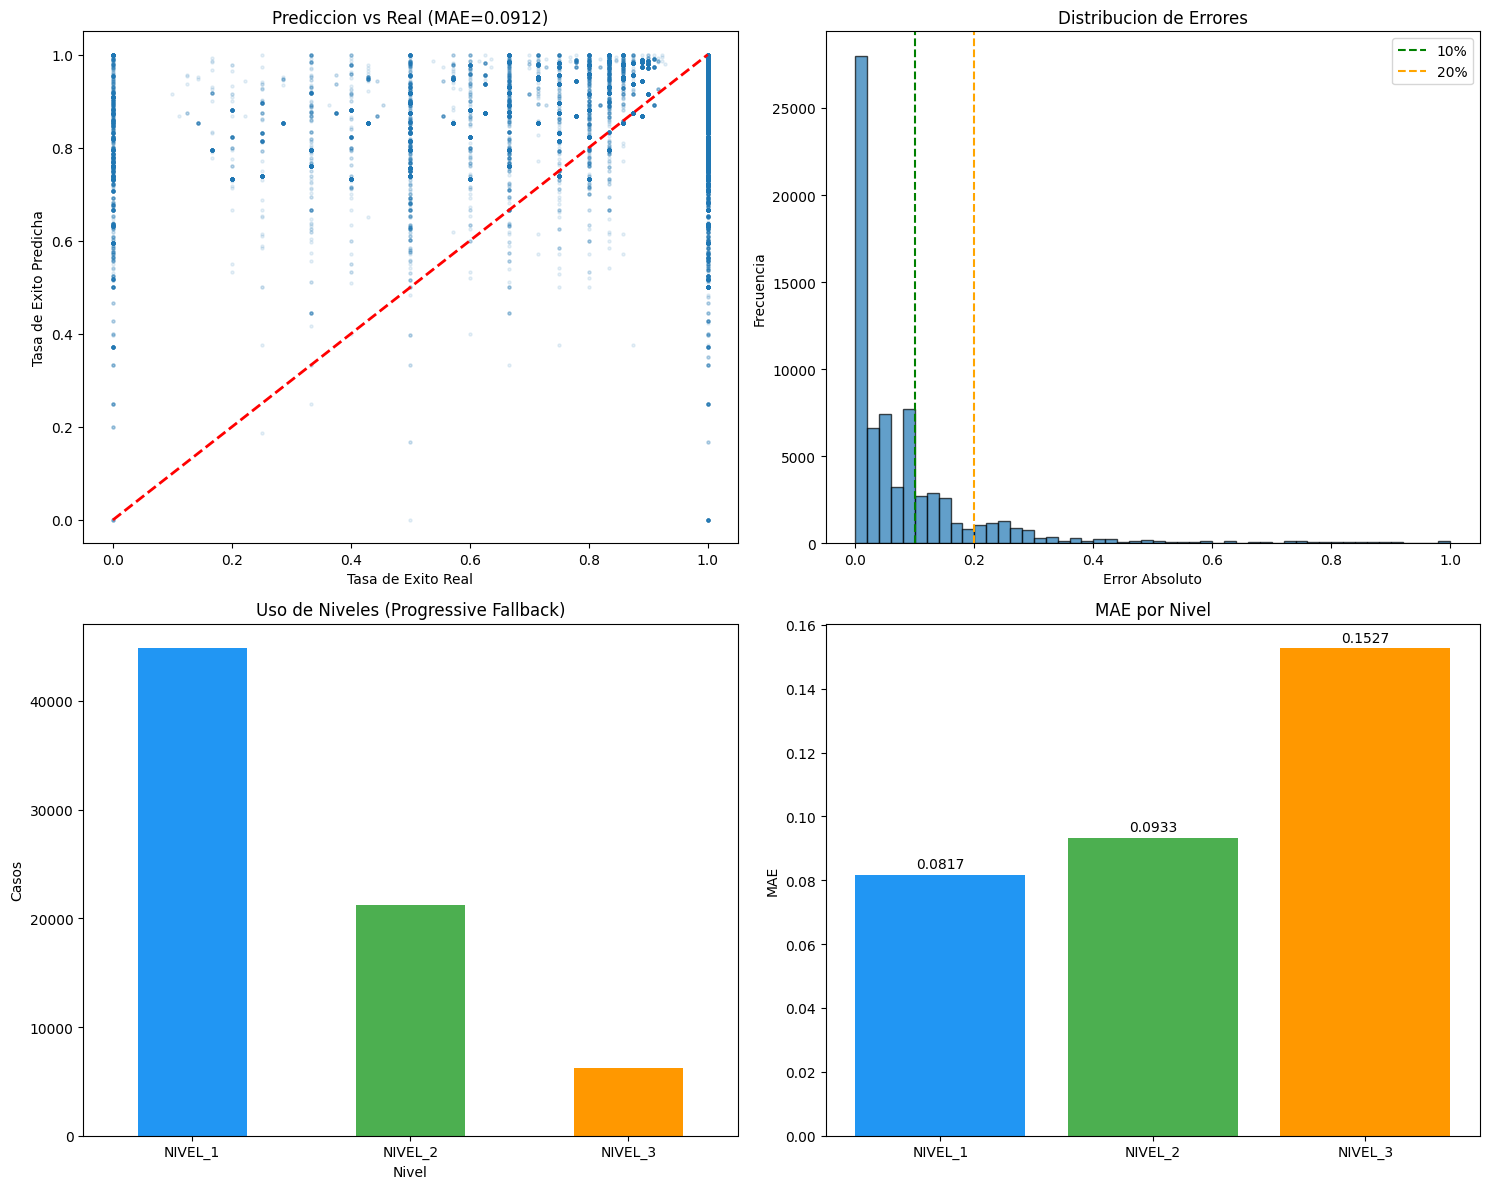

Visualizaciones guardadas en docs/LADA_v5_resultados.png


In [12]:
# ============================================================================
# VISUALIZACIONES
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Prediccion vs Real
ax = axes[0, 0]
ax.scatter(reales, predicciones, alpha=0.1, s=5)
ax.plot([0, 1], [0, 1], 'r--', linewidth=2)
ax.set_xlabel('Tasa de Exito Real')
ax.set_ylabel('Tasa de Exito Predicha')
ax.set_title(f'Prediccion vs Real (MAE={mae:.4f})')

# 2. Distribucion de errores
ax = axes[0, 1]
ax.hist(errores, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(x=0.10, color='g', linestyle='--', label='10%')
ax.axvline(x=0.20, color='orange', linestyle='--', label='20%')
ax.set_xlabel('Error Absoluto')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribucion de Errores')
ax.legend()

# 3. Uso de niveles
ax = axes[1, 0]
niveles_counts = pd.Series(niveles_usados).value_counts()
niveles_counts.plot(kind='bar', ax=ax, color=['#2196F3', '#4CAF50', '#FF9800'])
ax.set_xlabel('Nivel')
ax.set_ylabel('Casos')
ax.set_title('Uso de Niveles (Progressive Fallback)')
ax.tick_params(axis='x', rotation=0)

# 4. MAE por nivel
ax = axes[1, 1]
mae_por_nivel = {}
for nivel_nombre in ['NIVEL_1', 'NIVEL_2', 'NIVEL_3']:
    mask_n = np.array(niveles_usados) == nivel_nombre
    if mask_n.any():
        mae_por_nivel[nivel_nombre] = mean_absolute_error(reales[mask_n], predicciones[mask_n])
if mae_por_nivel:
    bars = ax.bar(mae_por_nivel.keys(), mae_por_nivel.values(), color=['#2196F3', '#4CAF50', '#FF9800'])
    ax.set_ylabel('MAE')
    ax.set_title('MAE por Nivel')
    for bar, val in zip(bars, mae_por_nivel.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{val:.4f}', ha='center')

plt.tight_layout()
plt.savefig('../docs/LADA_v5_resultados.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualizaciones guardadas en docs/LADA_v5_resultados.png")

In [ ]:
# ============================================================================
# RESULTADOS DE SELECCION DE ALGORITMO GLOBAL
# ============================================================================
print("SELECCION DE ALGORITMO GLOBAL - RESUMEN")
print("=" * 70)

print(f"\nAlgoritmo seleccionado: {ALGORITMO_GANADOR.upper()}")
print(f"\nMAE promedio global por algoritmo (pool de todas las muestras de 3 niveles):")
for algo in ['fuzzy', 'kmeans', 'gmm']:
    maes = mae_pool_por_algoritmo.get(algo, [])
    if maes:
        marker = " <-- GANADOR" if algo == ALGORITMO_GANADOR else ""
        print(f"  {algo.upper():>8}: MAE={np.mean(maes):.4f} +/- {np.std(maes):.4f} (n={len(maes)}){marker}")

print(f"\nMuestra estadistica (Cochran, 95% confianza, 5% margen):")
for nivel, info in muestras_por_nivel.items():
    print(f"  {nivel}: {info['muestra']} de {info['total']} combinaciones")

print(f"\nResultados finales en TEST:")
print(f"  MAE:         {mae:.4f}")
print(f"  Acc +/-10%:  {acc_10:.1f}%")
print(f"  Acc +/-20%:  {acc_20:.1f}%")
print(f"  Cobertura:   {cobertura:.1f}% ({len(predicciones):,}/{len(test_firmas):,})")
print(f"  Test cases:  {len(predicciones):,} ({PCT_TEST_EVALUAR*100:.0f}% del test)")

print(f"\nNota: v4 tenia dos bugs criticos:")
print(f"  1. range(1) en vez de range(10): solo probaba 1 configuracion por algoritmo")
print(f"  2. sample(n=2000): solo evaluaba 2,000 casos de test")
print(f"  3. Solo buscaba algoritmo en NIVEL_1 y propagaba ciegamente a NIVEL_2/3")

In [14]:
# ============================================================================
# EXPORTACION DEL MODELO
# ============================================================================
os.makedirs("../models_2", exist_ok=True)

modelo_lada = {
    "resultados_por_nivel": resultados_por_nivel,
    "scaler_nivel1": scaler_nivel1,
    "mapeo_curso_cat": mapeo_curso_cat,
    "FEATURE_COLS": FEATURE_COLS,
    "PARAM_SPACES": PARAM_SPACES,
    "usar_departamento_nivel2": usar_departamento_nivel2,
    "metricas_test": {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "Acc_10pct": float(acc_10),
        "Acc_20pct": float(acc_20),
        "Cobertura": float(cobertura),
        "n_test": len(predicciones),
        "n_test_total": len(test_firmas)
    },
    "version": "v5",
    "descripcion": "v4 metodologia + bug fixes (range(10), PCT_TEST_EVALUAR) + optimizaciones"
}

ruta_modelo = "../models_2/lada_modelo_v5.pkl"
with open(ruta_modelo, "wb") as f:
    pickle.dump(modelo_lada, f)

print(f"Modelo guardado en: {ruta_modelo}")
print(f"Tamano: {os.path.getsize(ruta_modelo) / (1024*1024):.1f} MB")

# Resumen final
print(f"\n{'='*70}")
print(f"RESUMEN EJECUTIVO - LADA v5")
print(f"{'='*70}")
print(f"  Estrategia: Level 1 propagation (por combinacion)")
print(f"  Random Search: {N_ITER_SEARCH} iteraciones x 3 algoritmos x {len(combinaciones_nivel1)} combinaciones")
print(f"  MAE:         {mae:.4f}")
print(f"  Acc +/-10%:  {acc_10:.1f}%")
print(f"  Acc +/-20%:  {acc_20:.1f}%")
print(f"  Cobertura:   {cobertura:.1f}%")
print(f"  Test cases:  {len(predicciones):,}")

Modelo guardado en: ../models_2/lada_modelo_v5.pkl
Tamano: 1.5 MB

RESUMEN EJECUTIVO - LADA v5
  Estrategia: Level 1 propagation (por combinacion)
  Random Search: 10 iteraciones x 3 algoritmos x 15 combinaciones
  MAE:         0.0912
  Acc +/-10%:  73.3%
  Acc +/-20%:  87.4%
  Cobertura:   100.0%
  Test cases:  72,274
